## NLTK

In [17]:
import os, certifi
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

In [72]:
from nltk.tokenize import word_tokenize
from nltk.text import Text

En NLTK, la función word_tokenize() depende del modelo preentrenado punkt, que contiene reglas y patrones para dividir el texto en palabras correctamente. Este paquete no viene por defecto en NLTK, por lo que hay que descargarlo manualmente la primera vez.

In [19]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#### 0. Importamos el data set

https://huggingface.co/datasets/huggingartists/metallica

In [20]:
%pip install datasets
#pip install --upgrade datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\tomas\ML\nlp\Scripts\python.exe -m pip install --upgrade pip


In [21]:
# daba error porque falta el paquete pyarrow
#%pip uninstall -y pyarrow
%pip install --no-cache-dir pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\tomas\ML\nlp\Scripts\python.exe -m pip install --upgrade pip


In [22]:
%pip install mlcroissant

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\tomas\ML\nlp\Scripts\python.exe -m pip install --upgrade pip


In [23]:
#import mlcroissant

In [24]:
from huggingface_hub import hf_hub_download

from datasets import load_dataset
# JSON
path = hf_hub_download(

    repo_id="huggingartists/metallica",
    repo_type="dataset",
    filename="datasets.json"
)
# Cargar JSON

ds = load_dataset("json", data_files=path, split="train")

print(ds)

Dataset({
    features: ['train'],
    num_rows: 1
})


In [25]:
lyrics = ds['train'][0]
# split lyrics into sentences usando nltk split usando comillas inglesas    

Las dos primeras canciones

In [26]:
lyrics[:2]


['So close, no matter how far\nCouldnt be much more from the heart\nForever trusting who we are\nAnd nothing else matters\nNever opened myself this way\nLife is ours, we live it our way\nAll these words I dont just say\nAnd nothing else matters\nTrust I seek and I find in you\nEveryday, for us, something new\nOpen mind for a different view\nAnd nothing else matters\nNever cared for what they do\nNever cared for what they know\nBut I know\nSo close, no matter how far\nIt couldnt be much more from the heart\nForever trusting who we are\nAnd nothing else matters\nNever cared for what they do\nNever cared for what they know\nBut I know\nI never opened myself this way\nLife is ours, we live it our way\nAll these words I dont just say\nAnd nothing else matters\nTrust I seek and I find in you\nEveryday, for us, something new\nOpen mind for a different view\nAnd nothing else matters\nNever cared for what they say\nNever cared for games they play\nNever cared for what they do\nNever cared for w

In [27]:
# lo paso a un dataframe

import pandas as pd

df = pd.DataFrame({"lyrics": lyrics})
df.head()


,lyrics
0,"So close, no matter how far\nCouldnt be much m..."
1,I cant remember anything\nCant tell if this is...
2,"Say your prayers, little one, dont forget, my ..."
3,"End of passion play, crumbling away\nIm your s..."
4,"New blood joins this Earth, and quickly hes su..."


In [28]:
one = df["lyrics"][1]
one

'I cant remember anything\nCant tell if this is true or a dream\nDeep down inside I feel to scream\nThis terrible silence stops me\nNow that the war is through with me\nIm waking up, I cannot see\nThat theres not much left of me\nNothing is real but pain now\nHold my breath as I wish for death\nOh please God, wake me\nBack in the womb its much too real\nIn pumps life that I must feel\nBut cant look forward to reveal\nLook to the time when Ill live\nFed through the tube that sticks in me\nJust like a wartime novelty\nTied to machines that make me be\nCut this life off from me\nHold my breath as I wish for death\nOh please God, wake me\nNow the world is gone, Im just one\nOh, God help me\nHold my breath as I wish for death\nOh please God, help me\nDarkness imprisoning me\nAll that I see, absolute horror\nI cannot live, I cannot die\nTrapped in myself, body my holding cell\nLandmine has taken my sight\nTaken my speech, taken my hearing\nTaken my arms, taken my legs\nTaken my soul, left me

#### 1.Tokenize
En NLTK, la función word_tokenize() depende del modelo preentrenado punkt, que contiene reglas y patrones para dividir el texto en palabras correctamente. Este paquete no viene por defecto en NLTK, por lo que hay que descargarlo manualmente la primera vez.


**1.1 Tokenizacion de oraciones**    
Para poder hacer tokenizacion de oraciones necesita de signos de puntiacion.

In [30]:
import re

df["clean"] = (
    df["lyrics"]
    .str.lower()
    .str.replace(r"\n", " ", regex=True)
    .str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)
)

df["clean"].head()

0    so close no matter how far couldnt be much mor...
1    i cant remember anything cant tell if this is ...
2    say your prayers little one dont forget my son...
3    end of passion play crumbling away im your sou...
4    new blood joins this earth and quickly hes sub...
Name: clean, dtype: object

In [31]:
df["lyrics"][1]

'I cant remember anything\nCant tell if this is true or a dream\nDeep down inside I feel to scream\nThis terrible silence stops me\nNow that the war is through with me\nIm waking up, I cannot see\nThat theres not much left of me\nNothing is real but pain now\nHold my breath as I wish for death\nOh please God, wake me\nBack in the womb its much too real\nIn pumps life that I must feel\nBut cant look forward to reveal\nLook to the time when Ill live\nFed through the tube that sticks in me\nJust like a wartime novelty\nTied to machines that make me be\nCut this life off from me\nHold my breath as I wish for death\nOh please God, wake me\nNow the world is gone, Im just one\nOh, God help me\nHold my breath as I wish for death\nOh please God, help me\nDarkness imprisoning me\nAll that I see, absolute horror\nI cannot live, I cannot die\nTrapped in myself, body my holding cell\nLandmine has taken my sight\nTaken my speech, taken my hearing\nTaken my arms, taken my legs\nTaken my soul, left me

Las letras de las canciones no tienes signos de puntiacion.

In [33]:
from nltk.tokenize import sent_tokenize

texto = df["lyrics"][1].replace("\n", ". ")
one_sent_tk = sent_tokenize(texto)
one_sent_tk

['I cant remember anything.',
 'Cant tell if this is true or a dream.',
 'Deep down inside I feel to scream.',
 'This terrible silence stops me.',
 'Now that the war is through with me.',
 'Im waking up, I cannot see.',
 'That theres not much left of me.',
 'Nothing is real but pain now.',
 'Hold my breath as I wish for death.',
 'Oh please God, wake me.',
 'Back in the womb its much too real.',
 'In pumps life that I must feel.',
 'But cant look forward to reveal.',
 'Look to the time when Ill live.',
 'Fed through the tube that sticks in me.',
 'Just like a wartime novelty.',
 'Tied to machines that make me be.',
 'Cut this life off from me.',
 'Hold my breath as I wish for death.',
 'Oh please God, wake me.',
 'Now the world is gone, Im just one.',
 'Oh, God help me.',
 'Hold my breath as I wish for death.',
 'Oh please God, help me.',
 'Darkness imprisoning me.',
 'All that I see, absolute horror.',
 'I cannot live, I cannot die.',
 'Trapped in myself, body my holding cell.',
 'Lan

Otra manera de tokenizar con split y apoyandonos en '\n' que separa cada oracion

In [34]:
one = df.loc[1, "lyrics"]  # sin limpiar
one_sent_tk2 = one.split("\n")
one_sent_tk2

['I cant remember anything',
 'Cant tell if this is true or a dream',
 'Deep down inside I feel to scream',
 'This terrible silence stops me',
 'Now that the war is through with me',
 'Im waking up, I cannot see',
 'That theres not much left of me',
 'Nothing is real but pain now',
 'Hold my breath as I wish for death',
 'Oh please God, wake me',
 'Back in the womb its much too real',
 'In pumps life that I must feel',
 'But cant look forward to reveal',
 'Look to the time when Ill live',
 'Fed through the tube that sticks in me',
 'Just like a wartime novelty',
 'Tied to machines that make me be',
 'Cut this life off from me',
 'Hold my breath as I wish for death',
 'Oh please God, wake me',
 'Now the world is gone, Im just one',
 'Oh, God help me',
 'Hold my breath as I wish for death',
 'Oh please God, help me',
 'Darkness imprisoning me',
 'All that I see, absolute horror',
 'I cannot live, I cannot die',
 'Trapped in myself, body my holding cell',
 'Landmine has taken my sight',
 

**1.2 Tokenizacion de palabras**

Aplico tokenizacion de palabras sobre la cancion normalizada

In [35]:
from nltk.tokenize import word_tokenize

one = df.loc[1, "clean"]
tokens = word_tokenize(one)

tokens[:30]   # para ver las primeras palabras


['i',
 'cant',
 'remember',
 'anything',
 'cant',
 'tell',
 'if',
 'this',
 'is',
 'true',
 'or',
 'a',
 'dream',
 'deep',
 'down',
 'inside',
 'i',
 'feel',
 'to',
 'scream',
 'this',
 'terrible',
 'silence',
 'stops',
 'me',
 'now',
 'that',
 'the',
 'war',
 'is']

Puedo tokenizar todos los documentos

In [36]:
from nltk.tokenize import word_tokenize
df["tokens"] = df["clean"].apply(word_tokenize)
df["tokens"].head()


0    [so, close, no, matter, how, far, couldnt, be,...
1    [i, cant, remember, anything, cant, tell, if, ...
2    [say, your, prayers, little, one, dont, forget...
3    [end, of, passion, play, crumbling, away, im, ...
4    [new, blood, joins, this, earth, and, quickly,...
Name: tokens, dtype: object

Todos los tokens en una lista

In [37]:
all_tokens = [token for song in df["tokens"] for token in song]
all_tokens

['so',
 'close',
 'no',
 'matter',
 'how',
 'far',
 'couldnt',
 'be',
 'much',
 'more',
 'from',
 'the',
 'heart',
 'forever',
 'trusting',
 'who',
 'we',
 'are',
 'and',
 'nothing',
 'else',
 'matters',
 'never',
 'opened',
 'myself',
 'this',
 'way',
 'life',
 'is',
 'ours',
 'we',
 'live',
 'it',
 'our',
 'way',
 'all',
 'these',
 'words',
 'i',
 'dont',
 'just',
 'say',
 'and',
 'nothing',
 'else',
 'matters',
 'trust',
 'i',
 'seek',
 'and',
 'i',
 'find',
 'in',
 'you',
 'everyday',
 'for',
 'us',
 'something',
 'new',
 'open',
 'mind',
 'for',
 'a',
 'different',
 'view',
 'and',
 'nothing',
 'else',
 'matters',
 'never',
 'cared',
 'for',
 'what',
 'they',
 'do',
 'never',
 'cared',
 'for',
 'what',
 'they',
 'know',
 'but',
 'i',
 'know',
 'so',
 'close',
 'no',
 'matter',
 'how',
 'far',
 'it',
 'couldnt',
 'be',
 'much',
 'more',
 'from',
 'the',
 'heart',
 'forever',
 'trusting',
 'who',
 'we',
 'are',
 'and',
 'nothing',
 'else',
 'matters',
 'never',
 'cared',
 'for',
 'w

Convertimos todos los documentos en texto NLTK

In [38]:
t = Text(all_tokens)
t

<Text: so close no matter how far couldnt be...>

#### 2. Algunas funciones 

**2.1 concordance()**  
La función concordance() en NLTK sirve para buscar palabras dentro de un corpus y mostrar el contexto en el que aparecen.

In [39]:
t.concordance('god')

Displaying 25 of 90 matches:
 breath as i wish for death oh please god wake me back in the womb its much too
 breath as i wish for death oh please god wake me now the world is gone im just
 now the world is gone im just one oh god help me hold my breath as i wish for 
 breath as i wish for death oh please god help me darkness imprisoning me all t
 cant be happening to me who made you god to say ill take your life from you fl
l the flame someone help me oh please god help me theyre trying to take it all 
want to die someone help me oh please god help me theyre trying to take it all 
rawl in yourself youll have your time god ill make them pay take it back one da
 back by the deepened nail follow the god that failed find your peace find your
 back by the deepened nail follow the god that failed yeah i see faith in your 
 back by the deepened nail follow the god that failed pride you took pride you 
 back by the deepened nail follow the god that failed follow the god that faile
follow the 

**2.2 t.collocations()**  
t.collocations() se usa para encontrar combinaciones frecuentes de palabras en un texto. Estas combinaciones, llamadas colocaciones, son pares o grupos de palabras que aparecen juntas con mayor frecuencia de lo esperado por azar, como "inteligencia artificial" o "aprendizaje profundo".

In [40]:
t.collocations() 

tick tick; searching seek; else matters; hey hey; master master;
nothing else; yeah yeah; may roam; nevernever land; faster obey;
destroy searching; never cared; shortest straw; bell tolls; dub thee;
small town; sun city; enter night; thee unforgiven; exit light


**2.3 count()**
conteo de una palabra concreta

In [41]:
t.count('life')

359

**2.4 index**  
lugar de aparicion de la palabra

In [42]:
t.index('life')

27

**2.5 similar()**  
similar busca palabras similares por el contexto en el que aparece. Requiere de varias apariciones

In [43]:
t.similar('life')

eyes way song mind time world money heart name face band it you me
pain back day friend shit loverman


**2.6 FreqDist**   
Palabras mas frecuentes

In [44]:
from nltk.probability import FreqDist
from nltk.corpus import stopwords
import string

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

t_filtered = [word.lower() for word in t if word.isalnum() and word.lower() not in stop_words]

freq_dist = FreqDist(t_filtered)

# Mostrar las 20 palabras más frecuentes
print("\n**Palabras más comunes en el corpus:**\n")
print(freq_dist.most_common(20))


**Palabras más comunes en el corpus:**

[('im', 919), ('yeah', 869), ('dont', 573), ('never', 569), ('know', 543), ('see', 489), ('like', 479), ('one', 474), ('time', 458), ('cant', 389), ('take', 381), ('life', 359), ('come', 323), ('oh', 317), ('got', 317), ('say', 306), ('way', 299), ('go', 288), ('away', 284), ('man', 279)]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


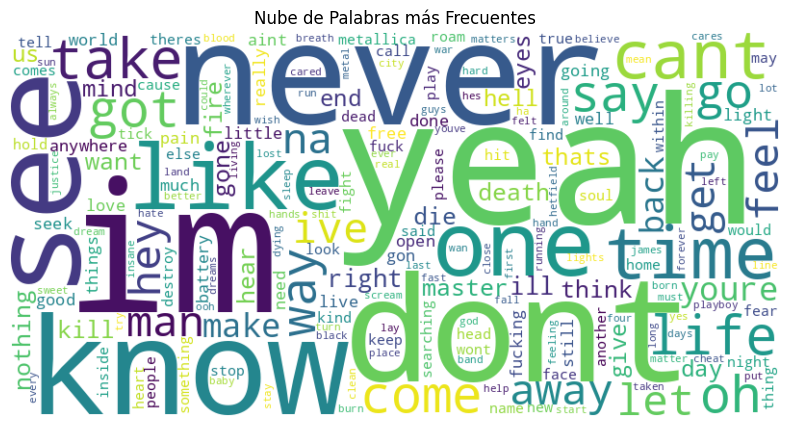

In [45]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq_dist)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras más Frecuentes")
plt.show()

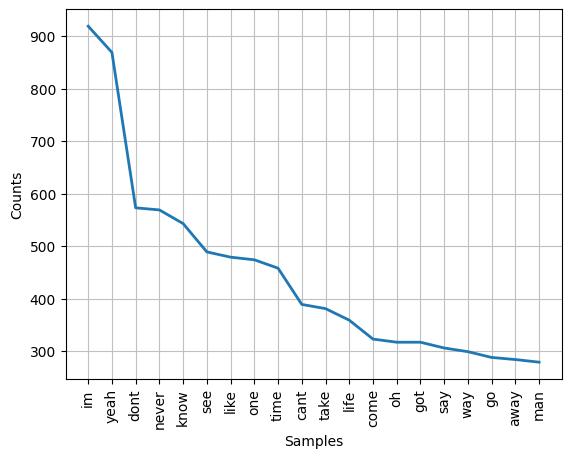

In [46]:
t2=Text(t_filtered).plot(20) # plots 20 most common tokens

**2.7 Dispersion Plot** 

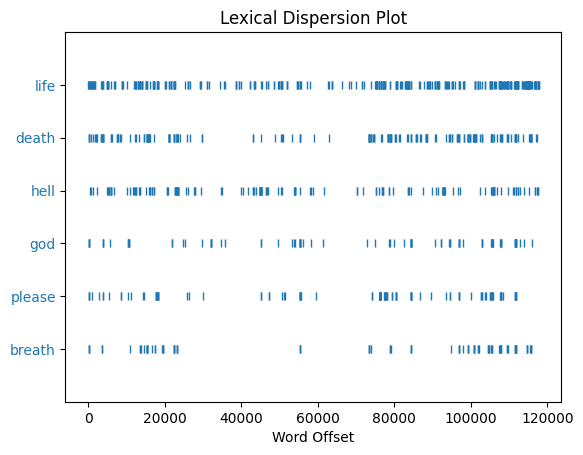

In [47]:
t.dispersion_plot(['life', 'death', 'hell', 'god', 'please', 'breath'])

#### 2.8 Stemmer
Stemmer extrae la raiz de las palabras

In [48]:
import nltk
from nltk.stem import PorterStemmer

# Inicializar el stemmer
stemmer = PorterStemmer()

# Lista de palabras para aplicar stemming
palabras = ["running", "runner", "runs", "easily", "fairly"]

# Aplicar stemming a cada palabra
palabras_stemmed = [stemmer.stem(word) for word in palabras]

print("\nPalabras originales:", palabras)
print("Palabras después de stemming:", palabras_stemmed)



Palabras originales: ['running', 'runner', 'runs', 'easily', 'fairly']
Palabras después de stemming: ['run', 'runner', 'run', 'easili', 'fairli']


**Stemmer con snowball en Español**

In [49]:
from nltk.stem import (PorterStemmer, LancasterStemmer)
from nltk.stem.snowball import SnowballStemmer # This is "Porter 2" and is considered the optimal stemmer.

# ejemplo de stemmers 

porter = PorterStemmer()
lancaster = LancasterStemmer()
snowball = SnowballStemmer("spanish")

texto = "El procesamiento de lenguaje natural es fascinante."

tokens1 = word_tokenize(texto, language='spanish')
tokens1 = [word.lower() for word in tokens1]
#tokens1[:15]


tokens1_stemmed = [snowball.stem(word) for word in tokens1]

print("\nPalabras originales:", tokens1)
print("Palabras después de stemming:", tokens1_stemmed)



Palabras originales: ['el', 'procesamiento', 'de', 'lenguaje', 'natural', 'es', 'fascinante', '.']
Palabras después de stemming: ['el', 'proces', 'de', 'lenguaj', 'natural', 'es', 'fascin', '.']


**Stemmer con Porter**

In [50]:
import nltk
from nltk.stem import PorterStemmer

# Inicializar el stemmer
stemmer = PorterStemmer()
one = df.loc[1, "clean"]

tokens_one = word_tokenize(one, language='english')
tokens_one = [word.lower() for word in tokens_one]
tokens_one[:15]

t_one= Text(tokens_one)
# Lista de palabras de ejemplo

# Aplicar stemming a cada palabra
palabras_stemmed = [stemmer.stem(word) for word in t_one]

# Unir los resultados en un string tokenizado por espacios
resultado = " ".join(palabras_stemmed)

print(resultado)  # Salida esperada: 


i cant rememb anyth cant tell if thi is true or a dream deep down insid i feel to scream thi terribl silenc stop me now that the war is through with me im wake up i can not see that there not much left of me noth is real but pain now hold my breath as i wish for death oh pleas god wake me back in the womb it much too real in pump life that i must feel but cant look forward to reveal look to the time when ill live fed through the tube that stick in me just like a wartim novelti tie to machin that make me be cut thi life off from me hold my breath as i wish for death oh pleas god wake me now the world is gone im just one oh god help me hold my breath as i wish for death oh pleas god help me dark imprison me all that i see absolut horror i can not live i can not die trap in myself bodi my hold cell landmin ha taken my sight taken my speech taken my hear taken my arm taken my leg taken my soul left me with life in hell


#### 2.9 Lemmatizer

In [51]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.text import Text
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

# Inicializar el lematizador
lemmatizer = WordNetLemmatizer()

# Aplicar lematización a cada palabra
palabras_lemmatized = [lemmatizer.lemmatize(word) for word in t_one]

# Unir los resultados en un string tokenizado por espacios
resultado = " ".join(palabras_lemmatized)

print(resultado)  # Salida con palabras lematizadas


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


i cant remember anything cant tell if this is true or a dream deep down inside i feel to scream this terrible silence stop me now that the war is through with me im waking up i can not see that there not much left of me nothing is real but pain now hold my breath a i wish for death oh please god wake me back in the womb it much too real in pump life that i must feel but cant look forward to reveal look to the time when ill live fed through the tube that stick in me just like a wartime novelty tied to machine that make me be cut this life off from me hold my breath a i wish for death oh please god wake me now the world is gone im just one oh god help me hold my breath a i wish for death oh please god help me darkness imprisoning me all that i see absolute horror i can not live i can not die trapped in myself body my holding cell landmine ha taken my sight taken my speech taken my hearing taken my arm taken my leg taken my soul left me with life in hell


#### 2.10 Normalizamos one  
Aplicamos el proceso completo de normalizacion a la canción One

In [52]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# 1. minusculas

one = df.loc[1, "clean"]
one_lower=one.lower()
print("Lowercased one:", one_lower)


# 2. Removing punctuation
one_no_punct = re.sub(r'[^\w\s]', '', one_lower)
print("One without punctuation:", one_no_punct)

# 3. Tokenization
words = nltk.word_tokenize(one_no_punct)
print("Tokenized words:", words)


# 4. Removing stop words
stop_words = set(stopwords.words('english'))
words_no_stop = [word for word in words if word not in stop_words]
print("Text without stopwords:", words_no_stop)

# 5. Stemming
ps = PorterStemmer()
words_stemmed = [ps.stem(word) for word in words_no_stop]
print("Stemmed words:", words_stemmed)

# 6. Lemmatization
lemmatizer = WordNetLemmatizer()
words_lemmatized = [lemmatizer.lemmatize(word) for word in words_no_stop]
print("Lemmatized words:", words_lemmatized)



Lowercased one: i cant remember anything cant tell if this is true or a dream deep down inside i feel to scream this terrible silence stops me now that the war is through with me im waking up i cannot see that theres not much left of me nothing is real but pain now hold my breath as i wish for death oh please god wake me back in the womb its much too real in pumps life that i must feel but cant look forward to reveal look to the time when ill live fed through the tube that sticks in me just like a wartime novelty tied to machines that make me be cut this life off from me hold my breath as i wish for death oh please god wake me now the world is gone im just one oh god help me hold my breath as i wish for death oh please god help me darkness imprisoning me all that i see absolute horror i cannot live i cannot die trapped in myself body my holding cell landmine has taken my sight taken my speech taken my hearing taken my arms taken my legs taken my soul left me with life in hell
One witho

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Freuencia de palabras: One lematized**


**Palabras más comunes en el corpus:**

[('taken', 6), ('hold', 4), ('oh', 4), ('god', 4), ('cant', 3), ('wake', 3), ('breath', 3), ('wish', 3), ('death', 3), ('pleas', 3), ('life', 3), ('feel', 2), ('im', 2), ('see', 2), ('much', 2), ('left', 2), ('real', 2), ('look', 2), ('live', 2), ('help', 2)]


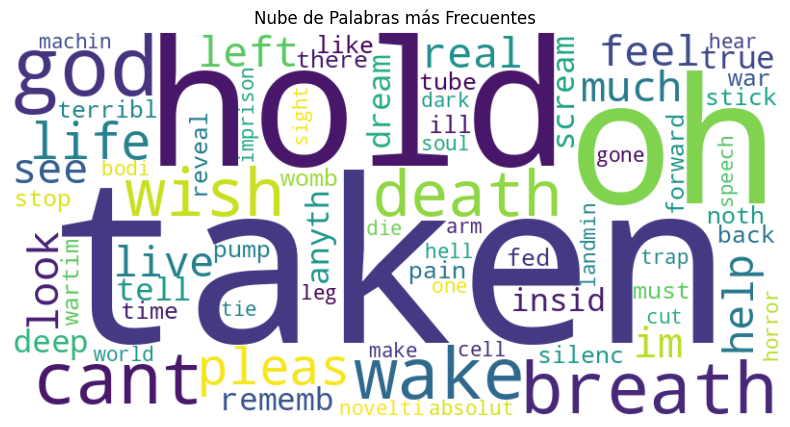

In [53]:
freq_dist = FreqDist(words_stemmed)

# Mostrar las 20 palabras más frecuentes
print("\n**Palabras más comunes en el corpus:**\n")
print(freq_dist.most_common(20))

import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq_dist)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras más Frecuentes")
plt.show()

#### 2.11 POS: Part of Speech

In [54]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import cess_esp

# Descargar corpus en español
nltk.download("cess_esp")
nltk.download("punkt")
nltk.download('averaged_perceptron_tagger_eng')

# Texto de ejemplo
texto = "I love learning algebra"

# Tokenizar el texto
tokens = word_tokenize(texto, language="english")

# Obtener etiquetas POS desde el corpus CESS-ESP
tagged_words = nltk.pos_tag(tokens, lang="eng")

print(tagged_words)


[nltk_data] Downloading package cess_esp to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package cess_esp is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


[('I', 'PRP'), ('love', 'VBP'), ('learning', 'VBG'), ('algebra', 'NN')]


In [56]:
# imprime solo las etiquetas de las palabras
print([tag for word, tag in tagged_words])


['PRP', 'VBP', 'VBG', 'NN']


In [57]:
tokens[1]

'love'

**POS con stanza**

In [55]:
pip install stanza

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\tomas\ML\nlp\Scripts\python.exe -m pip install --upgrade pip


In [58]:
# nltk pos solo está disponible en ingles y ruso
# scapy da muchos problemas para instlarse al menos ewn 3.12 y 3.13

import stanza #otro paquete de hugging face desarrollado en la universidad de Stanford

# Descargar el modelo de español (solo la primera vez)
stanza.download("es")

# Cargar el modelo de procesamiento en español
nlp = stanza.Pipeline("es", processors="tokenize,pos")

# Texto de ejemplo
texto = "El procesamiento de lenguaje natural es fascinante."

# Aplicar el modelo NLP
doc = nlp(texto)

# Obtener tokens y etiquetas POS
pos_tags = [(word.text, word.upos) for sentence in doc.sentences for word in sentence.words]

# Mostrar los resultados
print(pos_tags)


2026-01-21 05:49:27 INFO: Downloaded file to C:\Users\tomas\stanza_resources\resources.json
2026-01-21 05:49:27 INFO: Downloading default packages for language: es (Spanish) ...
2026-01-21 05:49:30 INFO: File exists: C:\Users\tomas\stanza_resources\es\default.zip
2026-01-21 05:49:36 INFO: Finished downloading models and saved to C:\Users\tomas\stanza_resources
2026-01-21 05:49:36 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-01-21 05:49:37 INFO: Downloaded file to C:\Users\tomas\stanza_resources\resources.json
2026-01-21 05:49:37 WARNING: Language es package default expects mwt, which has been added
2026-01-21 05:49:37 INFO: Loading these models for language: es (Spanish):
| Processor | Package         |
-------------------------------
| tokenize  | combined        |
| mwt       | combined        |
| pos       | combined_charlm |

2026-01-21 05:49:37 INFO: Using device: cpu
2026-01-21 05:49:37 INFO: Loading: tokenize
2026-01-21 05:49:40 INFO: Loading: mwt
2026-01-21 05:49:41 INFO: Loading: pos
2026-01-21 05:49:43 INFO: Done loading processors!


[('El', 'DET'), ('procesamiento', 'NOUN'), ('de', 'ADP'), ('lenguaje', 'NOUN'), ('natural', 'ADJ'), ('es', 'AUX'), ('fascinante', 'ADJ'), ('.', 'PUNCT')]


In [ ]:
%pip install spacy
%pip install https://github.com/explosion/spacy-models/releases/download/es_core_news_sm-3.7.0/es_core_news_sm-3.7.0-py3-none-any.whl

#### POS con Spacy

In [59]:
import spacy

# Cargar el modelo de español
nlp = spacy.load("es_core_news_sm")

# Texto de ejemplo
texto = "El procesamiento de lenguaje natural es fascinante."

# Procesar el texto
doc = nlp(texto)

# Obtener tokens y etiquetas POS
pos_tags = [(token.text, token.pos_) for token in doc]

print(pos_tags)


[('El', 'DET'), ('procesamiento', 'NOUN'), ('de', 'ADP'), ('lenguaje', 'NOUN'), ('natural', 'ADJ'), ('es', 'AUX'), ('fascinante', 'ADJ'), ('.', 'PUNCT')]


#### 2.12 NER

In [60]:
all_tokens = [token for song in df["tokens"] for token in song]
all_tokens[:21]

['so',
 'close',
 'no',
 'matter',
 'how',
 'far',
 'couldnt',
 'be',
 'much',
 'more',
 'from',
 'the',
 'heart',
 'forever',
 'trusting',
 'who',
 'we',
 'are',
 'and',
 'nothing',
 'else']

In [71]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk

# Descargar recursos necesarios
nltk.download("punkt")
nltk.download("maxent_ne_chunker")
nltk.download('maxent_ne_chunker_tab')
nltk.download("words")

#tokens = word_tokenize(MetallicA, language='english')
#tokens = [word.lower() for word in tokens]
#tokens[:15]

# Texto de ejemplo ya tokenizado (lista de palabras)


# Aplicar POS tagging a los tokens
pos_tags = pos_tag(all_tokens)


# Aplicar NER con ne_chunk()
ner_tree = ne_chunk(pos_tags)

# Mostrar las entidades nombradas

# Extraer solo las entidades nombradas
entities = [chunk.leaves()[0][0] for chunk in ner_tree if hasattr(chunk, "label")]

# Mostrar solo las palabras que son entidades
print(entities)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


TypeError: tokens: expected a list of strings, got a string

In [70]:
one

'I cant remember anything\nCant tell if this is true or a dream\nDeep down inside I feel to scream\nThis terrible silence stops me\nNow that the war is through with me\nIm waking up, I cannot see\nThat theres not much left of me\nNothing is real but pain now\nHold my breath as I wish for death\nOh please God, wake me\nBack in the womb its much too real\nIn pumps life that I must feel\nBut cant look forward to reveal\nLook to the time when Ill live\nFed through the tube that sticks in me\nJust like a wartime novelty\nTied to machines that make me be\nCut this life off from me\nHold my breath as I wish for death\nOh please God, wake me\nNow the world is gone, Im just one\nOh, God help me\nHold my breath as I wish for death\nOh please God, help me\nDarkness imprisoning me\nAll that I see, absolute horror\nI cannot live, I cannot die\nTrapped in myself, body my holding cell\nLandmine has taken my sight\nTaken my speech, taken my hearing\nTaken my arms, taken my legs\nTaken my soul, left me

para hacer la identificascion de entidadades no es necesario pasar el texto tokenizado

In [69]:
import spacy

# Cargar el modelo de español
nlp = spacy.load("es_core_news_sm")

# Texto de ejemplo (o tu lista de tokens unida)
#texto = "El procesamiento de lenguaje natural es fascinante y Google está invirtiendo mucho en ello."

# Procesar el texto
one = df.loc[1, "lyrics"]
doc = nlp(one)

# POS tagging
#pos_tags = [(token.text, token.pos_) for token in doc]
#print("POS tags:")
#print(pos_tags)

# NER (entidades nombradas)
entities = [(ent.text, ent.label_) for ent in doc.ents]
print("\nEntidades nombradas:")
print(entities)



Entidades nombradas:
[('Cant tell if this is true', 'MISC'), ('Deep down inside I feel to scream', 'MISC'), ('This terrible silence stops me\nNow that the war is through with me\nIm waking up', 'MISC'), ('I', 'MISC'), ('That theres not much left of me\nNothing is real but pain now\nHold my breath as I wish for death', 'MISC'), ('Oh please God', 'MISC'), ('Back in the womb', 'MISC'), ('In pumps life that I', 'MISC'), ('But cant look forward to reveal', 'MISC'), ('Look to the time when Ill', 'MISC'), ('Fed', 'ORG'), ('the tube that sticks in me\nJust like a wartime', 'MISC'), ('Tied to machines that make me be\nCut this life off from me\nHold my breath as I wish for death', 'MISC'), ('Oh please God', 'MISC'), ('wake me\nNow the world is gone', 'LOC'), ('Im just one\nOh,', 'MISC'), ('God help me\nHold my breath as I wish for death', 'MISC'), ('Oh please God', 'MISC'), ('help me\nDarkness imprisoning me\nAll that I', 'LOC'), ('I', 'MISC'), ('I', 'MISC'), ('Trapped in myself', 'MISC'), ('L

In [66]:
import spacy

# Cargar el modelo de español
nlp = spacy.load("es_core_news_sm")

# Frase de ejemplo
texto = "Metallica tocó en Madrid y James Hetfield habló con los fans."

# Procesar el texto
doc = nlp(texto)

# Extraer entidades nombradas
entities = [(ent.text, ent.label_) for ent in doc.ents]

print(entities)


[('Metallica', 'ORG'), ('Madrid', 'LOC'), ('James Hetfield', 'PER')]
